In [1]:
from common_helper_functions import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier
from scipy.stats import wilcoxon
import os

In [2]:
def plot_disease_embeddings_auprc(embedding_datasets, disease_datasets, save_dir="plots/AuPRC"):
    """
    For each disease dataset, compute auPRC across embeddings using XGBoost with 5-fold CV
    and generate grouped barplots with black dot fold results + significance annotations.
    
    Parameters
    ----------
    embedding_datasets : dict[str, pd.DataFrame]
        Dict of embeddings {name -> dataframe with gene_id and features}.
    disease_datasets : dict[str, pd.DataFrame]
        Dict of disease datasets {disease_name -> dataframe with gene_id and target (0/1)}.
    save_dir : str
        Directory to save plots.
    """
    os.makedirs(save_dir, exist_ok=True)

    # Define consistent color palette
    color_map = {
        "STRING": "#1f77b4",      # dark blue
        "STRING Exp": "#aec7e8",  # light blue
        "PoPS": "#2ca02c",        # green
        "PoPS Exp": "#98df8a",    # light green
        "Omics": "#ff7f0e"        # orange
    }

    results = []  # collect fold-wise results

    # CV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for disease_name, target_df in disease_datasets.items():
        for emb_name, emb_df in embedding_datasets.items():
            try:
                # Merge on gene_id
                merged = emb_df.merge(target_df, on="gene_id", how="inner")
                merged.set_index("gene_id", inplace=True)
                X = merged.drop("target", axis=1, errors="ignore").select_dtypes(include=[np.number])
                y = merged["target"]

                fold_scores = []
                for train_idx, test_idx in cv.split(X, y):
                    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

                    clf = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
                    clf.fit(X_train, y_train)
                    y_prob = clf.predict_proba(X_test)[:, 1]
                    auprc = average_precision_score(y_test, y_prob)
                    fold_scores.append(auprc)

                    results.append({
                        "Disease": disease_name,
                        "Embedding": emb_name,
                        "Fold": len(fold_scores),
                        "auPRC": auprc
                    })

                print(f"{disease_name} - {emb_name}: mean auPRC = {np.mean(fold_scores):.3f}")

            except Exception as e:
                print(f"Error with {disease_name} / {emb_name}: {e}")
                continue

    results_df = pd.DataFrame(results)

    # Plotting
    plt.figure(figsize=(12, 6))
    sns.set(style="whitegrid", context="talk")

    # Mean bars
    sns.barplot(
        data=results_df,
        x="Disease", y="auPRC", hue="Embedding",
        ci=None, palette=color_map, edgecolor="black"
    )

    # Overlay black dots (fold results)
    sns.stripplot(
        data=results_df,
        x="Disease", y="auPRC", hue="Embedding",
        dodge=True, jitter=False, marker="o", alpha=0.8, color="black"
    )

    # Remove duplicate legends
    handles, labels = plt.gca().get_legend_handles_labels()
    n_embeds = len(embedding_datasets)
    plt.legend(handles[:n_embeds], labels[:n_embeds], bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.ylabel("auPRC")
    plt.title("XGBoost auPRC across diseases and embeddings (5-fold CV)")
    plt.xticks(rotation=25)

    plt.tight_layout()
    out_file = os.path.join(save_dir, "Disease_Embedding_auPRC.png")
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved plot: {out_file}")

    return results_df


Mito - STRING: mean auPRC = 0.561
Mito - STRING Exp: mean auPRC = 0.415
Mito - PoPS: mean auPRC = 0.389
Mito - PoPS Exp: mean auPRC = 0.324
Mito - Omics: mean auPRC = 0.346
Ophthalmology - STRING: mean auPRC = 0.487
Ophthalmology - STRING Exp: mean auPRC = 0.193
Ophthalmology - PoPS: mean auPRC = 0.290
Ophthalmology - PoPS Exp: mean auPRC = 0.154
Ophthalmology - Omics: mean auPRC = 0.049
Inborn errors of immunity - STRING: mean auPRC = 0.260
Inborn errors of immunity - STRING Exp: mean auPRC = 0.211
Inborn errors of immunity - PoPS: mean auPRC = 0.279
Inborn errors of immunity - PoPS Exp: mean auPRC = 0.148
Inborn errors of immunity - Omics: mean auPRC = 0.120
Neurology - STRING: mean auPRC = 0.350
Neurology - STRING Exp: mean auPRC = 0.112
Neurology - PoPS: mean auPRC = 0.156
Neurology - PoPS Exp: mean auPRC = 0.074
Neurology - Omics: mean auPRC = 0.075
Neuromuscular - STRING: mean auPRC = 0.553
Neuromuscular - STRING Exp: mean auPRC = 0.172
Neuromuscular - PoPS: mean auPRC = 0.170
Ne

/scratch/tmp/kurte/ipykernel_2293139/2755038828.py:71: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/scratch/tmp/kurte/ipykernel_2293139/2755038828.py:78: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


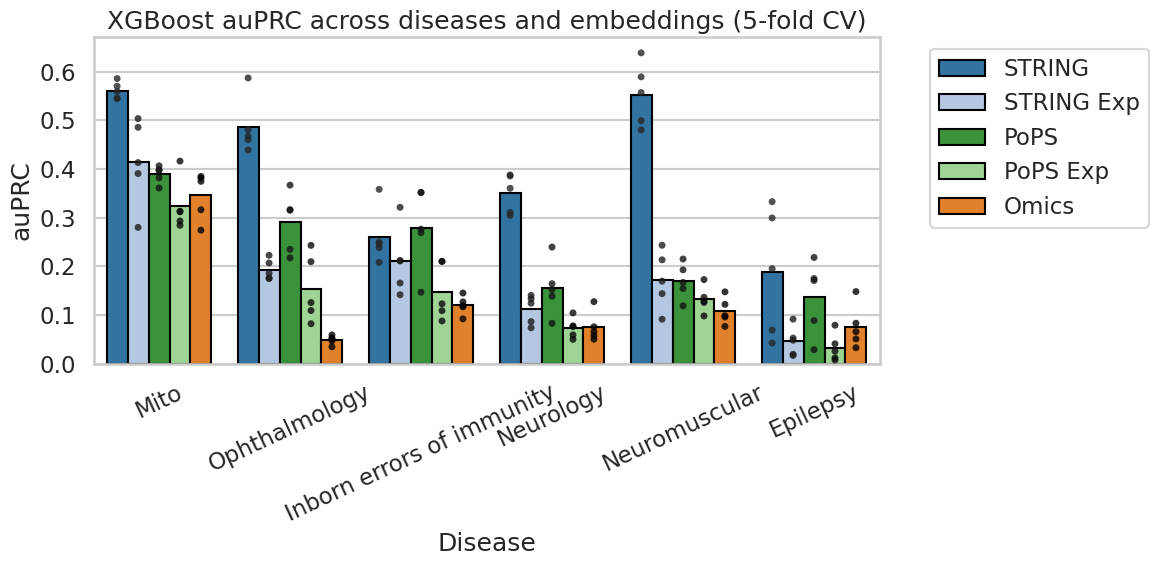

Saved plot: plots/AuPRC/Disease_Embedding_auPRC.png


In [3]:
embedding_datasets = {
    "STRING": string,
    "STRING Exp": string_exp,
    "PoPS": pops,
    "PoPS Exp": pops_exp,
    "Omics": omics
}

disease_datasets = {
    "Mito": mito,
    "Ophthalmology": opthamology,
    "Inborn errors of immunity": inborn_errors_immunity,
    "Neurology": neurology,
    "Neuromuscular": neuromuscular,
    "Epilepsy": epilepsy
}

results_df = plot_disease_embeddings_auprc(embedding_datasets, disease_datasets)